# 2. The different model classes

In this second tutorial, we will demonstrate the different models implemented in HMP. In this tutorial we will still be using simulated data, in the next tutorial we will show you how to use HMP on real data.

We will begin by simulating data with 5 events by calling the `demo` function, which is only used for this tutorial.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import hmp

# Running the demo function in the simulation module
from hmp.simulations import demo

# Simulating the data
n_events = 5 #how many events are simulated in the demo
# Performing simulation of trials
epoch_data, sim_source_times, info = demo()
# recovering average simulated times:
avg_simulated = np.mean(np.cumsum(sim_source_times,axis=1),axis=0) * 1000/epoch_data.sfreq

Simulating 0_raw.fif
0_raw.fif simulated
Processing dataset demo_dataset
Opening raw data file /home/gabriel/ownCloud/projects/RUGUU/hmp/docs/source/notebooks/sample_data/demo_dataset_raw.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 60) active
    Range : 0 ... 10378 =      0.000 ...   103.780 secs
Ready.
Reading 0 ... 10378  =      0.000 ...   103.780 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Removing existing average EEG reference projection.
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33 samp

/home/gabriel/ownCloud/projects/RUGUU/hmp/hmp/io/utils.py:18: UserWarning: No 'baseline' provided, using default value of (None, 0) seconds 
use 'epoching_kwargs' to override default values
  warn(f"No '{key}' provided, using default value of {value} seconds \n"


50 matching events found
Setting baseline interval to [-0.1, 0.0] s
Applying baseline correction (mode: mean)
Using data from preloaded Raw for 50 events and 211 original time points ...
0 bad epochs dropped


We preprocess the data as in Turorial 1, but this time we request 10 PC components (more on that in Tutorial 3 on real data). Instead of using the whole pipeline presented in Tutorial 1 we just call the function `basedata.default()` that contains all the steps and arguments seen in Tutorial 1. If you use the `default` method on your own data, realize that it performs several preprocessing steps with the standard parameters.

In [2]:
from hmp import basedata
hmp_data = basedata.default(
    epoch_data,
    duration_id = "response_time", #In which variable of epoch_data are the duration to be modelled
    offsets=0.03, # Adding 30ms before centering event and after duration end to pad for the crosscorrelation, not included in the data afterwards
    n_comp=10 # How many principal components to keep for the fit, the more the better
)

Found 50 trials with positively defined durations and 0 trials without durations (0 or nan)

Rejection summary: 
 0 trials rejected based on threshold of inf 
 0 trials rejected  based on duration limit of (0.01, inf) 
 0 with duration but without data (nan at time 0)


Nest, we create a standard template and distribution as in Tutorial 1, this will be used for all the model classes. If you do not provide a pattern, all model classes will assume a half-sine with a width of 50 ms.

In [3]:
from hmp.patterns import HalfSine
from hmp.patterndata import PatternData

pattern = HalfSine()
# Here we crosscorrelate the data once to avoid doing that at every fit call
pattern_data = PatternData.from_basedata(hmp_data, pattern=pattern)

## The `EventModel` class: modeling a fixed number of events.

This type of model is the *basic* model used by HMP and implements the basic HMP algorithm. All subsequent classes call this class.
The model works with an a priori number of events defined by the `n_events` parameter.

The EM algorithm (see previous documentation section [here](./1-How_HMP_works.ipynb)) is by default initiated with neutral starting points: all events are assumed to spread out evenly across the mean reaction time (RT), and no channels are contributing to the events. Below we specified `max_iteration = 0` to prevent going through the EM procedure to demonstrate those starting points.

In [4]:
from hmp.models import EventModel

model_null = EventModel(n_events = n_events,
                        max_iteration = 0 ) # max_iteration=0 prevents from actually going through the EM
model_null.fit(pattern_data, verbose=False) # to illustrate the default starting points

/home/gabriel/ownCloud/projects/RUGUU/hmp/hmp/models/event.py:633: RuntimeWarning: Convergence failed, estimation hit the maximum number of iterations: (0)
  warn(


In [5]:
model_null.time_pars

array([[[2.   , 5.955],
        [2.   , 5.955],
        [2.   , 5.955],
        [2.   , 5.955],
        [2.   , 5.955],
        [2.   , 5.955]]])

The RT equally divided by the events.

In [6]:
model_null.channel_pars

array([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]], dtype=float32)

And at the start, no channels contributing.

### Fit transform

As seen previously, when fitting an `EventModel` both the time and channel parameters will get updated depending on the data. The time parameters will be updated to reflect the expected time interval between each event, and the channel parameters will be updated to reflect the expected contribution of each channel to each event.

In [7]:
model = EventModel(n_events=n_events)

#Fitting and transforming the data
loglikelihood, estimates = model.fit_transform(pattern_data)# Fits the model and returns the estimates as event probabilities per sample

print('\ntime parameters:\n', model.time_pars)
print('\nchannel parameters:\n', model.channel_pars)

Estimating 5 events model

time parameters:
 [[[2.         2.83771944]
  [2.         7.90507603]
  [2.         4.85994196]
  [2.         7.14365673]
  [2.         8.80698013]
  [2.         3.67662597]]]

channel parameters:
 [[[-0.81701237  1.8438766   2.9500582  -2.04543    -0.06916369
    0.18806992 -0.33131602  0.1333288   0.06478871  0.03228069]
  [-2.9072044   0.792316   -0.99142367  0.5985628   0.7484706
   -1.4019493  -0.04328213 -0.27758825 -0.37756792 -0.10272097]
  [-2.3509655  -3.6550856  -0.63982916 -1.0404556  -0.4231166
    0.51757735  0.12324817  0.09525512  0.16968444  0.07039474]
  [-1.8419224   2.6192622  -1.6269464   0.6123598  -0.66295373
    1.2274414   0.2981836   0.20444426  0.05301234 -0.00844638]
  [ 0.43833375 -0.14327429  0.32378253  0.19760051  0.33822805
    0.03269753  0.1404649  -0.26525173 -0.24219665 -0.07217527]]]


As you can see, they have been updated from the neutral values above. Combined, these time and channel parameters define the event probabilities for each sample in the data, and provide the best fit to the data that HMP was able to find given the starting points.

The `estimates` variable contains the sample probabilities, which can be visualized using the `plot_topo_timecourse` function. We also visualized the simulated event times with `times_to_display`.

In [8]:
avg_simulated

array([ 57.8, 131. , 217.4, 311.4, 461.4, 704.6])

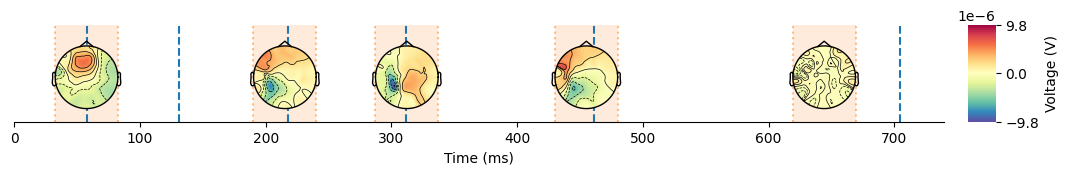

In [9]:
from hmp.visu import plot_topo_timecourse

#Visualizing
plot_topo_timecourse(epoch_data, estimates, info, magnify=1, sensors=False, times_to_display=avg_simulated)

In this case HMP misses the 2nd event, which is not very surprising as it is very close to the 1st one, and all events are grouped towards the first half of the trial (the last line indicates the average RT). The reason is that the EM algorithm is sensitive to the starting points, which are by default evenly spread across the RT. We developed several methods to alleviate this problem, and we recommend never just fitting an `EventModel` with a fixed number of events.

## Informed starting points

As a first method, the user can specify starting points. Obviously, this is only useful if you have a good hypothesis on where the events should be, or perhaps if you want to find an event at a specific time (e.g, P300). Based on what we know about the simulation, here we specified 3 shorter intervals followed by several longer ones.

Estimating 5 events model


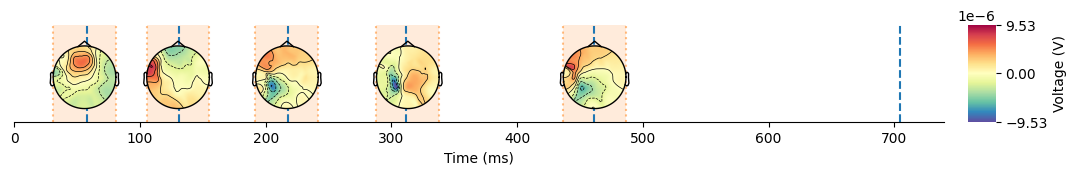

In [10]:
time_parameters = np.array([[2, 2.5], # Expecting a shorter inter-event duration
                            [2, 2.5], # Expecting a shorter inter-event duration
                            [2, 2.5], # Expecting a shorter inter-event duration
                            [2, 10],  # Expecting a longer inter-event duration
                            [2, 10],  # Expecting a longer inter-event duration
                            [2, 20]]) # Expecting a much longer inter-event duration
# Estimating an informed model
ll_informed, estimates_informed = model.fit_transform(pattern_data, time_pars=time_parameters)# Providing the informed starting points

# Visualisation
plot_topo_timecourse(epoch_data, estimates_informed, info, magnify=1, sensors=False, times_to_display=avg_simulated)

Hooray, the 2nd event is now found! The reason is that the starting points are now more appropriate for the data. However, typically we don't know the starting points to expect, so we will now look at how to use multiple random starting points.

## Random starting points

To avoid leaving parameter space unexplored, we will now generate 100 random starting points, and return the fit with the higehst loglikelihood.

Estimating 5 events model


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=147974) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


  0%|          | 0/100 [00:00<?, ?it/s]

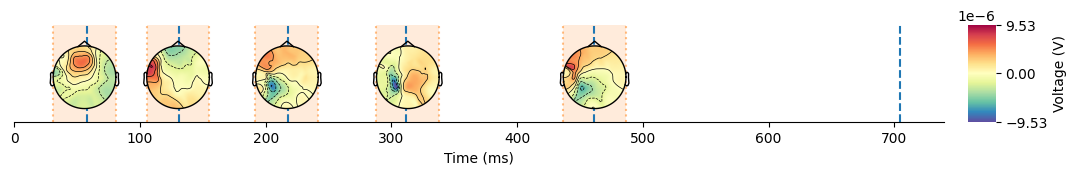

In [11]:
model_random = EventModel(pattern = pattern, n_events=n_events, 
                        starting_points=100, max_duration=pattern_data.durations.max())
ll_random, estimates_random = model_random.fit_transform(pattern_data, cpus=2, )

#Visualizing
plot_topo_timecourse(epoch_data, estimates_random, info, magnify=1, sensors=False, times_to_display=avg_simulated)

Provided enough starting point the method will find the correct solution, here you typically find the correct solution with 100 starting points. However, random starting points are typically not the best solution, especially when the number of events is high or if the duration you model (e.g. RT) is very long. In that case, we can use the eliminative or cumulative estimation methods.

## Eliminative method

The Eliminative method first estimates a model with the maximal number of possible events that fit in the shortest RT (referred to as 'the maximal model'), and then decrease the number of events one by one.

The idea is that genuine events will necessarily be found at the expected locations in the maximal model. Because the backward estimation method iteratively removes the weakest event (in terms of likelihood), only the 'strongest' events remain even if their location would have been hard to find with a single fit and default starting values.

In order to do this we will use the ```EliminativeMethod```. This function first estimates the maximal number of event (defined based on the event width and the minimum reaction time)  using an ```EventModel```, then estimates the max_event - 1 solution by iteratively removing one of the events and picking the solution with the highest likelihood (for more details see Borst & Anderson, [2021](http://jelmerborst.nl/pubs/ACTR_hmp_MVPA_BorstAnderson_preprint.pdf)) and repeat this until the 1 event solution is reached.

As the next step, we typically apply Leave-One-Out Cross Validation LOOCV to determine the model that is warranted given the data. See Tutorial 5 for details.

### Default behavior

In [12]:
from hmp.models import EliminativeMethod

elim_model = EliminativeMethod()
ll_elim, estimates_elim = elim_model.fit_transform(pattern_data, cpus=2)

Max event that can be fit given minimum duration of 40 is 9
9
Estimating all solutions for maximal number of events (9)


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=147974) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


Estimating all solutions for 8 events


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=147974) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


  0%|          | 0/9 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

Estimating all solutions for 1 events


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=147974) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


  0%|          | 0/2 [00:00<?, ?it/s]

/home/gabriel/ownCloud/projects/RUGUU/hmp/hmp/models/eliminative.py:179: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'event' ('event',) The recommendation is to set join explicitly for this case.
  xr_eventprobs = xr.concat(event_probs, dim=pd.Index(list(self.submodels), name="n_events"))


Here we plot the resulting solutions going from the maximal possible number of events (here 9 given the simulated average RT) all the way to a single event. 

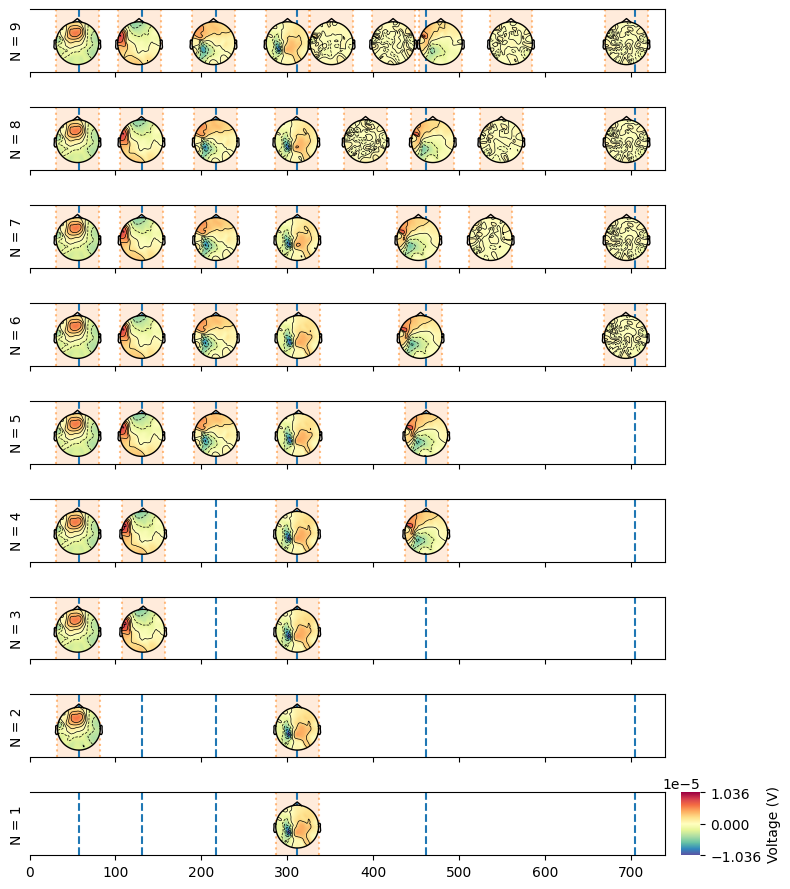

In [13]:
hmp.visu.plot_model(epoch_data, estimates_elim, info, as_time=True, times_to_display=avg_simulated)

We can see that the maximal model contains the true topograpies and also some false alarms as we requested too many events compared to the true ones. We see that at each removal one of these false alarm gets removed. In this case, it's quite clear what the false alarms are, but with real data that is often more difficult to determine.

From the solutions of the backward estimation we can select the number of events we originally wanted to estimate.

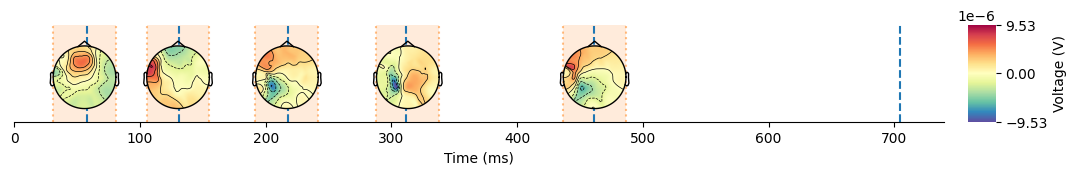

In [14]:
selected = estimates_elim.sel(n_events=n_events)
plot_topo_timecourse(epoch_data, selected, info, sensors=False, times_to_display=avg_simulated)

In this case this is also the maximum likelihood solution, as shown in the plot below. In general, the likelihood is evolving in a complex manner with the number of events. On the one hand adding events tends to increase the likelihood, on the other hand if events start to compete for samples (see the maximum model where the third event is split in two), the likelihood can decrease. This is why we can see that the likelihood is not monotonically increasing with the number of events. To counter this issue we typically apply LOOCV, where we fit the model on n-1 subjects and calculate the likelihood of the nth subjects, basically identifying the model that generalizes best across subjects.

Text(0, 0.5, 'Log-likelihood')

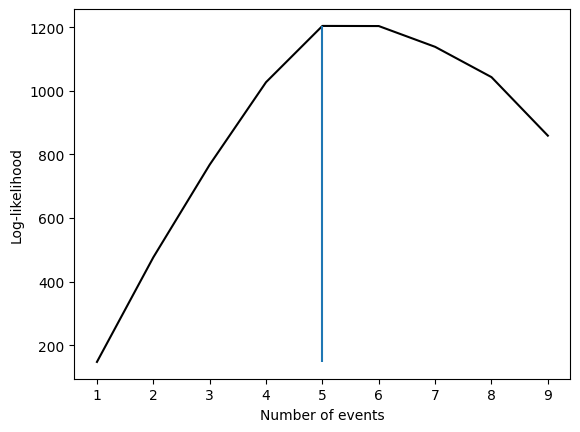

In [15]:
n_events_backward = [elim_model.submodels[i].n_events for i in elim_model.submodels]
plt.plot(n_events_backward, ll_elim, 'k')
plt.vlines(n_events, np.min(ll_elim), np.max(ll_elim))
plt.xlabel('Number of events')
plt.ylabel('Log-likelihood')

### Providing a custom maximum model

Instead of simply estimating a model with a maximum number of events we can provide a custom maximum model. This is useful if we know that the maximum number of events is lower than the one estimated by the `EliminativeMethod` class or if we want to depart from a specific model, or if we want to use random starting points for the maximum model. In this case, we can provide a custom `EventModel` to the `EliminativeMethod` class and start the elimination from there.

Estimating 6 events model


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=147974) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


  0%|          | 0/50 [00:00<?, ?it/s]

Max event that can be fit given minimum duration of 40 is 9
9
Estimating all solutions for 5 events


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=147974) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


...

  0%|          | 0/3 [00:00<?, ?it/s]

Estimating all solutions for 1 events


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=147974) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


  0%|          | 0/2 [00:00<?, ?it/s]

/home/gabriel/ownCloud/projects/RUGUU/hmp/hmp/models/eliminative.py:179: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'event' ('event',) The recommendation is to set join explicitly for this case.
  xr_eventprobs = xr.concat(event_probs, dim=pd.Index(list(self.submodels), name="n_events"))


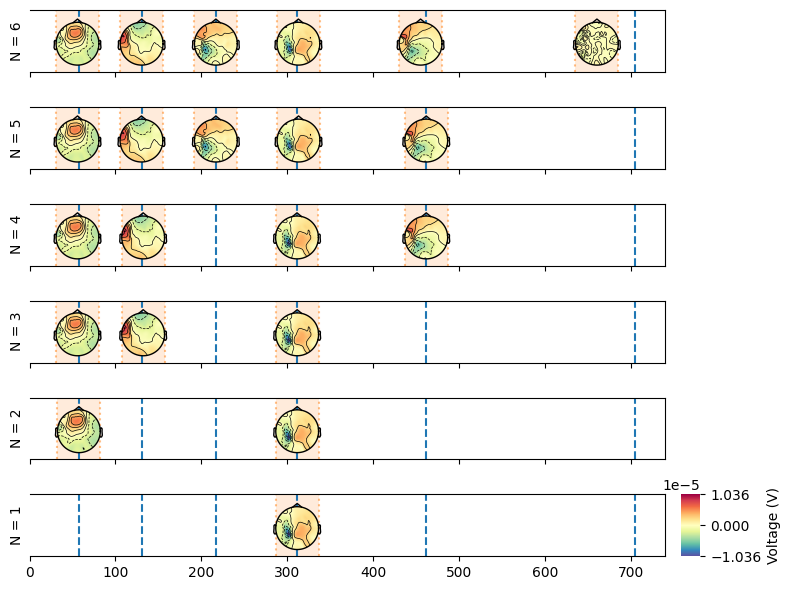

In [16]:
model_random = EventModel(pattern = pattern, n_events=6, 
                        starting_points=50, max_duration=pattern_data.durations.max())
ll_random, estimates_random = model_random.fit_transform(pattern_data, cpus=2)

elim_model_custom = EliminativeMethod(base_fit=model_random)
ll_elim_custom, estimates_elim_custom = elim_model_custom.fit_transform(pattern_data, cpus=2)

hmp.visu.plot_model(epoch_data, estimates_elim_custom, info, as_time=True, times_to_display=avg_simulated)

### Define a range

Finally, we can  specify a range if we don't want to fully explore all solutions:

8
Estimating all solutions for maximal number of events (8)
Estimating all solutions for 7 events
Estimating all solutions for 6 events
Estimating all solutions for 5 events
Estimating all solutions for 4 events
Estimating all solutions for 3 events


/home/gabriel/ownCloud/projects/RUGUU/hmp/hmp/models/eliminative.py:179: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'event' ('event',) The recommendation is to set join explicitly for this case.
  xr_eventprobs = xr.concat(event_probs, dim=pd.Index(list(self.submodels), name="n_events"))


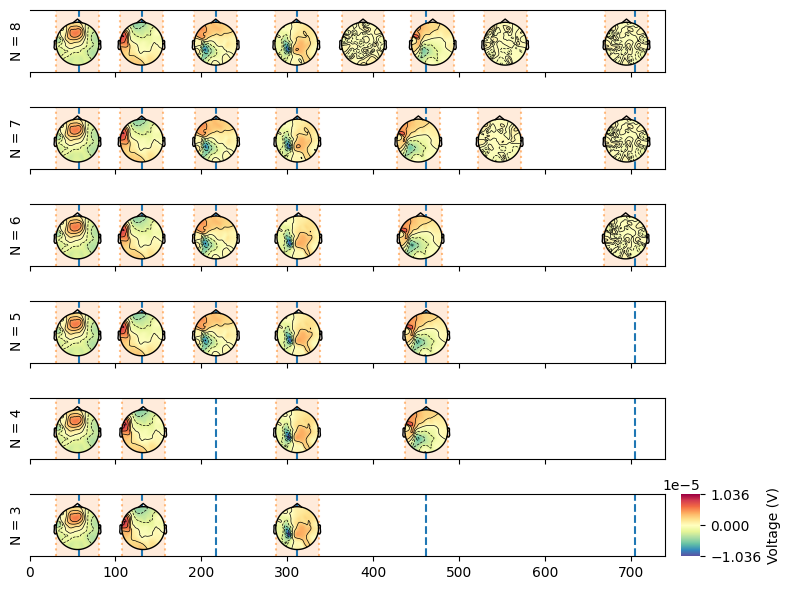

In [17]:
elim_model_range = EliminativeMethod(pattern = pattern, max_events=8, min_events=3)
ll_range, estimates_range = elim_model_range.fit_transform(pattern_data)
hmp.visu.plot_model(epoch_data, estimates_range, info, as_time=True, times_to_display=avg_simulated)

## Cumulative event fit

The final method that we often use is the Cumulative method. Instead of fitting an _n_ event model, this method starts by fitting a 1-event model iteratively using each sample from the time 0 (stimulus onset) to the mean RT. Therefore it tests for the landing point of the expectation maximization algorithm given each sample as starting point and the likelihood associated with this landing point. As soon as a starting points reaches the convergence criterion, the function fits an _n+1_ event model and uses the next samples in the RT for the following event, etc. Please see for details [this paper](https://direct.mit.edu/imag/article/doi/10.1162/imag_a_00400/125469/Trial-by-trial-detection-of-cognitive-events-in).

In [18]:
from hmp.models import CumulativeMethod
model_cumulative = CumulativeMethod()
ll_cumulative, estimates_cumulative = model_cumulative.fit_transform(pattern_data)

Max event that can be fit given minimum duration of 40 is 9


  0%|          | 0/26 [00:00<?, ?it/s]

1 events found around times [60]
2 events found around times [60, 130]
3 events found around times [60, 130, 220]
4 events found around times [60, 130, 310, 460]
5 events found around times [60, 130, 220, 310, 460]


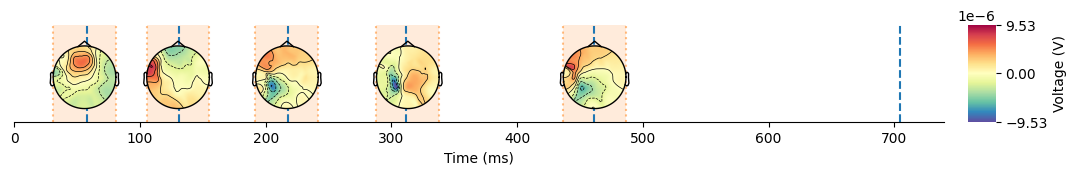

In [19]:
plot_topo_timecourse(epoch_data, estimates_cumulative, info, magnify=1, sensors=False, times_to_display=avg_simulated)

This method is in this case slightly too sensitive and identifies a 6th event. Remember that we're working with a very limited dataset here, which might be the cause of this extra event. Alternatively, one could also use the cumulative method in combination with LOOCV to discover the 'true' events.

In the next tutorial, we will apply these methods to a real dataset, albeit of only 5 participants to keep it manageble.